## Editing efficiency, ABE focused v1 and v2

In [187]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

In [188]:
fp1 = 'crispresso/focused'
fp2 = 'crispresso/fsr'
ABE_BC_RAW = sorted(os.listdir(f'{fp1}/ABE_BC'))
ABE_EPO_RAW = sorted(os.listdir(f'{fp1}/ABE_EPO'))
ABE_BC_v2_RAW = sorted(os.listdir(f'{fp2}/ABE_BC'))
ABE_EPO_v2_RAW = sorted(os.listdir(f'{fp2}/ABE_EPO'))

#set filters for minimum number of sensor reads
min_sensor_reads = 50
name_dict = { 'spleen':'Spleen', 'bm':'Bone Marrow', 'd5':'D5', 'd15':'D15', 'lib':'Plasmid', 'input':'Input (D0)'}

blues  = sns.color_palette('Blues').as_hex()
teals  = sns.color_palette('BuPu').as_hex()
edit_palette = [blues[4], teals[2]]


In [189]:
FOCUSED = pd.read_csv(BASE + 'MBESv2_focused.csv')
ABE = FOCUSED[(FOCUSED['Editor']=='ABE') & (FOCUSED['classification']=='targeting guide')]

In [190]:
t = []
corr = []
name = []

# bm1/3/5, d15 rep1-3, d5, input, lib, spleen1/3
ABE_BC_RAW_USED = [ABE_BC_RAW[i] for i in [0,2,4, 5,6,7, 10,11,12, 13,15]]
list_samples = ['bm']*3+['d15']*3+['d5','input','lib']+['spleen']*2

for i in ABE_BC_RAW_USED:
    g = pd.read_csv(f'{fp1}/ABE_BC/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
    g2 = pd.merge(g, ABE, on='gRNA_id')
    g2 = g2[g2['Reads_aligned_all_amplicons']>=min_sensor_reads]
    t.append(np.average(g2['target_base_edit_perc']))
    corr.append(np.average(g2['corr_perc']))

In [191]:
ABE_BC_RAW

['bm1_compact_unfiltered.csv',
 'bm2_compact_unfiltered.csv',
 'bm3_compact_unfiltered.csv',
 'bm4_compact_unfiltered.csv',
 'bm5_compact_unfiltered.csv',
 'd15-rep1_compact_unfiltered.csv',
 'd15-rep2_compact_unfiltered.csv',
 'd15-rep3_compact_unfiltered.csv',
 'd15-rep4_compact_unfiltered.csv',
 'd15-rep5_compact_unfiltered.csv',
 'd5_compact_unfiltered.csv',
 'input_compact_unfiltered.csv',
 'lib_compact_unfiltered.csv',
 'spleen1_compact_unfiltered.csv',
 'spleen2_compact_unfiltered.csv',
 'spleen3_compact_unfiltered.csv',
 'spleen4_compact_unfiltered.csv',
 'spleen5_compact_unfiltered.csv']

In [192]:
name = [name_dict[x] for x in list_samples]
ABE_BC_editing1 = pd.DataFrame(dict(zip(['Sample', 'Editing %',], [name, t,])))
ABE_BC_editing2 = pd.DataFrame(dict(zip(['Sample', 'Editing %'], [name, corr])))
ABE_BC_editing1['Edit Type'] = 'Target Editing (w/ Bystanders)'
ABE_BC_editing2['Edit Type'] = 'Pure Correct Editing'
ABE_BC_EDITING = pd.concat((ABE_BC_editing1, ABE_BC_editing2))

In [193]:
t = []
corr = []
name = []

# bm1-5, d15 1-3, input only (no input1/input2), spleen1/2/4/5 (no spleen3)
ABE_BC_v2_RAW_USED = [ABE_BC_v2_RAW[i] for i in [0,1,2,3,4, 5,6,7, 10, 11,12,13,14]]
list_samples = ['bm']*5+['d15']*3+['input']+['spleen']*4

for i in ABE_BC_v2_RAW_USED:
    g = pd.read_csv(f'{fp2}/ABE_BC/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
    g2 = pd.merge(g, ABE, on='gRNA_id')
    g2 = g2[g2['Reads_aligned_all_amplicons']>=min_sensor_reads]
    t.append(np.average(g2['target_base_edit_perc']))
    corr.append(np.average(g2['corr_perc']))

In [194]:
ABE_BC_v2_RAW

['bm1_compact_unfiltered.csv',
 'bm2_compact_unfiltered.csv',
 'bm3_compact_unfiltered.csv',
 'bm4_compact_unfiltered.csv',
 'bm5_compact_unfiltered.csv',
 'd15-rep1_compact_unfiltered.csv',
 'd15-rep2_compact_unfiltered.csv',
 'd15-rep3_compact_unfiltered.csv',
 'input1_compact_unfiltered.csv',
 'input2_compact_unfiltered.csv',
 'input_compact_unfiltered.csv',
 'spleen1_compact_unfiltered.csv',
 'spleen2_compact_unfiltered.csv',
 'spleen4_compact_unfiltered.csv',
 'spleen5_compact_unfiltered.csv']

In [195]:
ABE_BC_v2_RAW_USED

['bm1_compact_unfiltered.csv',
 'bm2_compact_unfiltered.csv',
 'bm3_compact_unfiltered.csv',
 'bm4_compact_unfiltered.csv',
 'bm5_compact_unfiltered.csv',
 'd15-rep1_compact_unfiltered.csv',
 'd15-rep2_compact_unfiltered.csv',
 'd15-rep3_compact_unfiltered.csv',
 'input_compact_unfiltered.csv',
 'spleen1_compact_unfiltered.csv',
 'spleen2_compact_unfiltered.csv',
 'spleen4_compact_unfiltered.csv',
 'spleen5_compact_unfiltered.csv']

In [196]:
ABE_BC_v2_RAW

['bm1_compact_unfiltered.csv',
 'bm2_compact_unfiltered.csv',
 'bm3_compact_unfiltered.csv',
 'bm4_compact_unfiltered.csv',
 'bm5_compact_unfiltered.csv',
 'd15-rep1_compact_unfiltered.csv',
 'd15-rep2_compact_unfiltered.csv',
 'd15-rep3_compact_unfiltered.csv',
 'input1_compact_unfiltered.csv',
 'input2_compact_unfiltered.csv',
 'input_compact_unfiltered.csv',
 'spleen1_compact_unfiltered.csv',
 'spleen2_compact_unfiltered.csv',
 'spleen4_compact_unfiltered.csv',
 'spleen5_compact_unfiltered.csv']

In [197]:
name = [name_dict[x] for x in list_samples]
ABE_BC_editing1 = pd.DataFrame(dict(zip(['Sample', 'Editing %',], [name, t,])))
ABE_BC_editing2 = pd.DataFrame(dict(zip(['Sample', 'Editing %'], [name, corr])))
ABE_BC_editing1['Edit Type'] = 'Target Editing (w/ Bystanders)'
ABE_BC_editing2['Edit Type'] = 'Pure Correct Editing'
ABE_BC_EDITING_V2 = pd.concat((ABE_BC_editing1, ABE_BC_editing2))

In [198]:
i = 'input_compact_unfiltered.csv'
g = pd.read_csv(f'{fp1}/ABE_EPO/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
g2 = pd.merge(g, ABE, on='gRNA_id')

In [199]:
t = []
corr = []
name = []

for i in ABE_EPO_RAW:
    print(i)
    g = pd.read_csv(f'{fp1}/ABE_EPO/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
    g2 = pd.merge(g, ABE, on='gRNA_id')
    g2 = g2[g2['Reads_aligned_all_amplicons']>=min_sensor_reads]
    t.append(np.average(g2['target_base_edit_perc']))
    corr.append(np.average(g2['corr_perc']))

list_samples = ['bm']*5+['d15']*5+['d5','input','lib']+['spleen']*5

name = [name_dict[x] for x in list_samples]
ABE_EPO_editing1 = pd.DataFrame(dict(zip(['Sample', 'Editing %',], [name, t,])))
ABE_EPO_editing2 = pd.DataFrame(dict(zip(['Sample', 'Editing %'], [name, corr])))
ABE_EPO_editing1['Edit Type'] = 'Target Editing (w/ Bystanders)'
ABE_EPO_editing2['Edit Type'] = 'Pure Correct Editing'
ABE_EPO_EDITING = pd.concat((ABE_EPO_editing1, ABE_EPO_editing2))

bm1_compact_unfiltered.csv
bm2_compact_unfiltered.csv
bm3_compact_unfiltered.csv
bm4_compact_unfiltered.csv
bm5_compact_unfiltered.csv
d15-rep1_compact_unfiltered.csv
d15-rep2_compact_unfiltered.csv
d15-rep3_compact_unfiltered.csv
d15-rep4_compact_unfiltered.csv
d15-rep5_compact_unfiltered.csv
d5_compact_unfiltered.csv
input_compact_unfiltered.csv
lib_compact_unfiltered.csv
spleen1_compact_unfiltered.csv
spleen2_compact_unfiltered.csv
spleen3_compact_unfiltered.csv
spleen4_compact_unfiltered.csv
spleen5_compact_unfiltered.csv


In [200]:
ABE_EPO_EDITING

,Sample,Editing %,Edit Type
0,Bone Marrow,84.267874,Target Editing (w/ Bystanders)
1,Bone Marrow,81.777630,Target Editing (w/ Bystanders)
2,Bone Marrow,79.392622,Target Editing (w/ Bystanders)
3,Bone Marrow,81.464935,Target Editing (w/ Bystanders)
4,Bone Marrow,85.275510,Target Editing (w/ Bystanders)
5,D15,82.987438,Target Editing (w/ Bystanders)
6,D15,83.632498,Target Editing (w/ Bystanders)
7,D15,84.709774,Target Editing (w/ Bystanders)
8,D15,82.858019,Target Editing (w/ Bystanders)
9,D15,81.773336,Target Editing (w/ Bystanders)


In [201]:
t = []
corr = []
name = []

# bm1-5, d15 1-3, input only (no input1/input2), spleen1-5
ABE_EPO_v2_RAW_USED = [ABE_EPO_v2_RAW[i] for i in [0,1,2,3,4, 5,6,7, 10, 11,12,13,14,15]]
list_samples = ['bm']*5+['d15']*3+['input']+['spleen']*5

for i in ABE_EPO_v2_RAW_USED:
    g = pd.read_csv(f'{fp2}/ABE_EPO/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
    g2 = pd.merge(g, ABE, on='gRNA_id')
    g2 = g2[g2['Reads_aligned_all_amplicons']>=min_sensor_reads]
    t.append(np.average(g2['target_base_edit_perc']))
    corr.append(np.average(g2['corr_perc']))

In [202]:
ABE_EPO_v2_RAW

['bm1_compact_unfiltered.csv',
 'bm2_compact_unfiltered.csv',
 'bm3_compact_unfiltered.csv',
 'bm4_compact_unfiltered.csv',
 'bm5_compact_unfiltered.csv',
 'd15-rep1_compact_unfiltered.csv',
 'd15-rep2_compact_unfiltered.csv',
 'd15-rep3_compact_unfiltered.csv',
 'input1_compact_unfiltered.csv',
 'input2_compact_unfiltered.csv',
 'input_compact_unfiltered.csv',
 'spleen1_compact_unfiltered.csv',
 'spleen2_compact_unfiltered.csv',
 'spleen3_compact_unfiltered.csv',
 'spleen4_compact_unfiltered.csv',
 'spleen5_compact_unfiltered.csv']

In [203]:

name = [name_dict[x] for x in list_samples]
ABE_EPO_editing1 = pd.DataFrame(dict(zip(['Sample', 'Editing %',], [name, t,])))
ABE_EPO_editing2 = pd.DataFrame(dict(zip(['Sample', 'Editing %'], [name, corr])))
ABE_EPO_editing1['Edit Type'] = 'Target Editing (w/ Bystanders)'
ABE_EPO_editing2['Edit Type'] = 'Pure Correct Editing'
ABE_EPO_EDITING_V2 = pd.concat((ABE_EPO_editing1, ABE_EPO_editing2))

In [204]:
ABE_EPO_EDITING_V2

,Sample,Editing %,Edit Type
0,Bone Marrow,76.696895,Target Editing (w/ Bystanders)
1,Bone Marrow,78.540210,Target Editing (w/ Bystanders)
2,Bone Marrow,78.132759,Target Editing (w/ Bystanders)
3,Bone Marrow,78.979566,Target Editing (w/ Bystanders)
4,Bone Marrow,78.222119,Target Editing (w/ Bystanders)
5,D15,79.454605,Target Editing (w/ Bystanders)
6,D15,80.133506,Target Editing (w/ Bystanders)
7,D15,79.083848,Target Editing (w/ Bystanders)
8,Input (D0),1.543210,Target Editing (w/ Bystanders)
9,Spleen,79.518963,Target Editing (w/ Bystanders)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


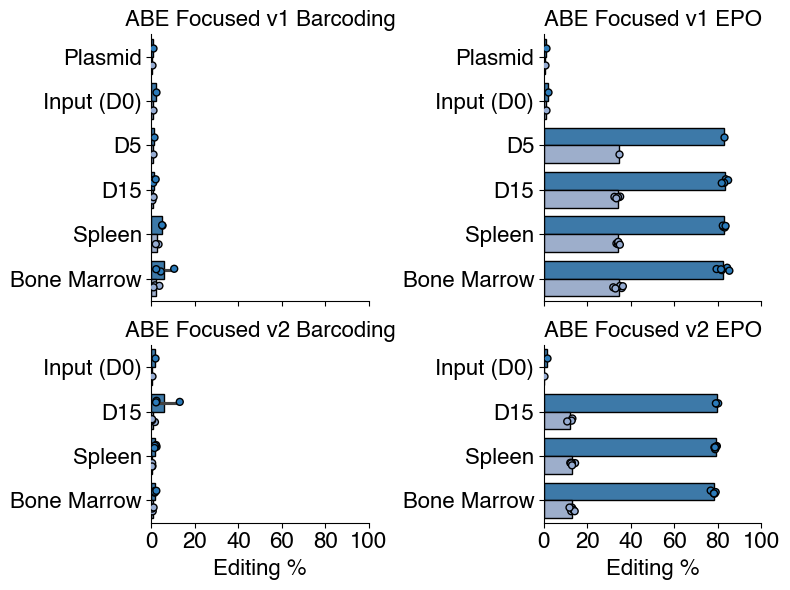

In [205]:
fig, ax = plt.subplots(2,2, figsize=(8,6), sharey=False, sharex=True,
                        gridspec_kw={'height_ratios': [6, 4]})
order_v1 = ['Plasmid', 'Input (D0)', 'D5', 'D15', 'Spleen', 'Bone Marrow']
order_v2 = ['Input (D0)', 'D15', 'Spleen', 'Bone Marrow']

sns.barplot(data = ABE_BC_EDITING, y='Sample', x='Editing %', hue='Edit Type', ax=ax[0][0], edgecolor='black', linewidth=1, palette = edit_palette, order=order_v1)
sns.barplot(data = ABE_EPO_EDITING, y='Sample', x='Editing %', hue='Edit Type', ax=ax[0][1], edgecolor='black', linewidth=1, palette = edit_palette, order=order_v1)
sns.barplot(data = ABE_BC_EDITING_V2, y='Sample', x='Editing %', hue='Edit Type', ax=ax[1][0], edgecolor='black', linewidth=1, palette = edit_palette, order=order_v2)
sns.barplot(data = ABE_EPO_EDITING_V2, y='Sample', x='Editing %', hue='Edit Type', ax=ax[1][1], edgecolor='black', linewidth=1, palette = edit_palette, order=order_v2)

sns.stripplot(data = ABE_BC_EDITING, y='Sample', x='Editing %', hue='Edit Type', ax=ax[0][0], edgecolor='black', linewidth=1, palette = edit_palette, order=order_v1, dodge=True, s=5)
sns.stripplot(data = ABE_EPO_EDITING, y='Sample', x='Editing %', hue='Edit Type', ax=ax[0][1], edgecolor='black', linewidth=1, palette = edit_palette, order=order_v1, dodge=True, s=5)
sns.stripplot(data = ABE_BC_EDITING_V2, y='Sample', x='Editing %', hue='Edit Type', ax=ax[1][0], edgecolor='black', linewidth=1, palette = edit_palette, order=order_v2, dodge=True, s=5)
sns.stripplot(data = ABE_EPO_EDITING_V2, y='Sample', x='Editing %', hue='Edit Type', ax=ax[1][1], edgecolor='black', linewidth=1, palette = edit_palette, order=order_v2, dodge=True, s=5)

ax[0][0].legend([],[], frameon=False)
ax[0][1].legend([],[], frameon=False)
ax[1][0].legend([],[], frameon=False)
ax[1][1].legend([],[], frameon=False)

ax[0][0].set_ylabel('')
ax[0][1].set_ylabel('')
ax[1][0].set_ylabel('')
ax[1][1].set_ylabel('')
ax[0][0].set_xticks([0,20,40,60,80,100])

ax[0][0].spines[['top', 'right']].set_visible(False)
ax[0][0].tick_params(axis='both', which='major', labelsize=16,)
ax[1][0].spines[['top', 'right']].set_visible(False)
ax[1][0].tick_params(axis='both', which='major', labelsize=16,)
ax[0][1].spines[['top', 'right']].set_visible(False)
ax[0][1].tick_params(axis='both', which='major', labelsize=16,)
ax[1][1].spines[['top', 'right']].set_visible(False)
ax[1][1].tick_params(axis='both', which='major', labelsize=16,)

ax[0][0].set_title('ABE Focused v1 Barcoding', fontsize = 16)
ax[0][1].set_title('ABE Focused v1 EPO', fontsize = 16)
ax[1][0].set_title('ABE Focused v2 Barcoding', fontsize = 16)
ax[1][1].set_title('ABE Focused v2 EPO', fontsize = 16)

ax[1][0].set_xlabel('Editing %', fontsize=16)
ax[1][1].set_xlabel('Editing %', fontsize=16)

fig.tight_layout()
fig.savefig('figures/supp/editing.pdf')

## Skew Ratio and PCA, ABE focused v1 and v2

In [206]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Palette (matches figure2_CLEANED)
blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

palette_skew = ['black', yellows[3], purples[2], purples[5], blues[3], greens[3]]
order_skew   = ['Plasmid', 'Input', 'D5', 'D15', 'Spleen', 'Bone Marrow']
order_skew_v2   = ['Input', 'D15', 'Spleen', 'Bone Marrow']  # no d5/lib in FSR screens
palette_skew_v2 = [yellows[3], purples[5], blues[3], greens[3]]  # Input, D15, Spleen, BM

# Load count tables
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'
FC_BC_COUNTS  = pd.read_csv(BASE + 'counts/focused/FC_ABE_BC_COUNTS.txt',  sep='\t')
FC_EPO_COUNTS = pd.read_csv(BASE + 'counts/focused/FC_ABE_EPO_COUNTS.txt', sep='\t')
FSR_BC_COUNTS  = pd.read_csv(BASE + 'counts/fsr/FSR_abe_bc_counts.csv')
FSR_EPO_COUNTS = pd.read_csv(BASE + 'counts/fsr/FSR_abe_epo_counts.csv')

# Sample lists (only used replicates, matching LFC analysis)
# v1 BC: bm1/3/5, d15-rep1/2/3, spleen1/3, d5, input, lib
v1_bc_samps  = ['bm1','bm3','bm5', 'd15-rep1','d15-rep2','d15-rep3', 'spleen1','spleen3', 'd5','input','lib']
# v2 BC: bm1-5, d15-1/2/3, spleen1/2/4/5, input
v2_bc_samps  = ['bm1','bm2','bm3','bm4','bm5', 'd15-1','d15-2','d15-3', 'spleen1','spleen2','spleen4','spleen5', 'input']
# v1 EPO: bm1-5, d15-rep1-5, spleen1-5, d5, input, lib
v1_epo_samps = ['bm1','bm2','bm3','bm4','bm5', 'd15-rep1','d15-rep2','d15-rep3','d15-rep4','d15-rep5',
                'spleen1','spleen2','spleen3','spleen4','spleen5', 'd5','input','lib']
# v2 EPO: bm1-5, d15-1/2/3, spleen1-5, input
v2_epo_samps = ['bm1','bm2','bm3','bm4','bm5', 'd15-1','d15-2','d15-3',
                'spleen1','spleen2','spleen3','spleen4','spleen5', 'input']

_tissue_label_map = {
    'bm': 'Bone Marrow', 'spleen': 'Spleen',
    'd15': 'D15', 'd5': 'D5',
    'lib': 'Plasmid', 'input': 'Input',
}

def _tissue_label(samp):
    for prefix, label in _tissue_label_map.items():
        if samp.startswith(prefix):
            return label
    return samp

def _skew_df(counts_df, samp_cols):
    rows = []
    for s in samp_cols:
        d = sorted(counts_df[s].values)
        n = len(d)
        ten    = d[int(0.1 * n)]
        ninety = d[int(0.9 * n)]
        ratio  = ninety / ten if ten > 0 else np.nan
        rows.append({'Sample': s, 'Name': _tissue_label(s), '90/10 Skew Ratio': ratio})
    return pd.DataFrame(rows)


In [ ]:
# 2×2 skew ratio: v1 BC, v1 EPO, v2 BC, v2 EPO
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharey=False, sharex=True,
                         gridspec_kw={'height_ratios': [6, 4]})

panels = [
    (FC_BC_COUNTS,  v1_bc_samps,  'ABE Focused v1 Barcoding', order_skew,    palette_skew),
    (FC_EPO_COUNTS, v1_epo_samps, 'ABE Focused v1 EPO',       order_skew,    palette_skew),
    (FSR_BC_COUNTS, v2_bc_samps,  'ABE Focused v2 Barcoding', order_skew_v2, palette_skew_v2),
    (FSR_EPO_COUNTS,v2_epo_samps, 'ABE Focused v2 EPO',       order_skew_v2, palette_skew_v2),
]

for ax, (counts, samps, title, order, pal) in zip(axes.flat, panels):
    df = _skew_df(counts, samps)
    _pal = pal[:len(order)]
    sns.barplot(data=df, y='Name', x='90/10 Skew Ratio', ax=ax,
                edgecolor='black', linewidth=1, palette=_pal, order=order)
    sns.stripplot(data=df, y='Name', x='90/10 Skew Ratio', ax=ax,
                  edgecolor='black', linewidth=1, palette=_pal, order=order, s=10)
    ax.set_xscale('log')
    ax.xaxis.set_major_locator(mpl.ticker.LogLocator(base=10, numticks=10))
    ax.xaxis.set_major_formatter(mpl.ticker.LogFormatterMathtext())
    ax.set_ylabel('')
    ax.set_xlabel('90/10 Skew Ratio', fontsize=14)
    ax.set_xlim(0, 50)
    ax.set_title(title, fontsize=14)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=14, length=6, width=1, direction='out')
    ax.tick_params(axis='x', which='minor', length=3, width=0.8, direction='out')

fig.tight_layout()
fig.savefig('figures/supp/skew.pdf', bbox_inches='tight')
plt.show()


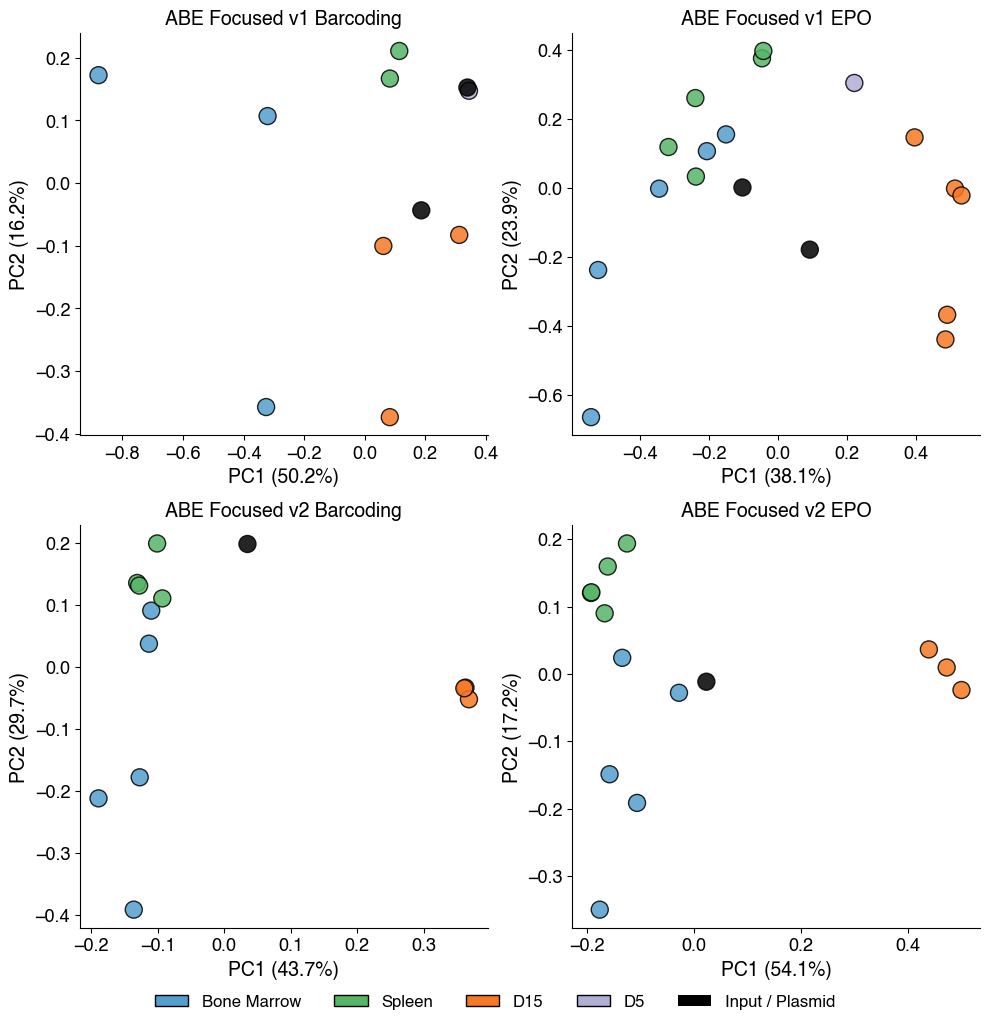

In [ ]:
# 2×2 PCA on Spearman correlation of sample counts
# Colour per tissue group: D15=yellows[3], Spleen=greens[3], BM=blues[3], Input/D5/Plasmid=black/grey
def _pca_colors(samp_cols):
    colors = []
    for s in samp_cols:
        lbl = _tissue_label(s)
        if lbl == 'Bone Marrow': colors.append(blues[3])
        elif lbl == 'Spleen':    colors.append(greens[3])
        elif lbl == 'D15':       colors.append(yellows[3])
        elif lbl == 'D5':        colors.append(purples[2])
        else:                    colors.append('black')
    return colors

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

pca_panels = [
    (FC_BC_COUNTS,   v1_bc_samps,  'ABE Focused v1 Barcoding'),
    (FC_EPO_COUNTS,  v1_epo_samps, 'ABE Focused v1 EPO'),
    (FSR_BC_COUNTS,  v2_bc_samps,  'ABE Focused v2 Barcoding'),
    (FSR_EPO_COUNTS, v2_epo_samps, 'ABE Focused v2 EPO'),
]

for ax, (counts, samps, title) in zip(axes.flat, pca_panels):
    mat = counts[samps].corr(method='spearman')
    pca = PCA(n_components=2)
    Xt  = pca.fit_transform(mat)
    colors = _pca_colors(samps)
    ax.scatter(Xt[:, 0], Xt[:, 1], c=colors, edgecolor='black', s=150, alpha=0.85)
    var = pca.explained_variance_ratio_
    ax.set_xlabel(f'PC1 ({np.round(var[0]*100,1)}%)', fontsize=14)
    ax.set_ylabel(f'PC2 ({np.round(var[1]*100,1)}%)', fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=13)

# Legend
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor=blues[3],   edgecolor='black', label='Bone Marrow'),
    Patch(facecolor=greens[3],  edgecolor='black', label='Spleen'),
    Patch(facecolor=yellows[3], edgecolor='black', label='D15'),
    Patch(facecolor=purples[2], edgecolor='black', label='D5'),
    Patch(facecolor='black',                       label='Input / Plasmid'),
]
fig.legend(handles=legend_elems, loc='lower center', ncol=5, fontsize=12,
           bbox_to_anchor=(0.5, -0.03), frameon=False)
fig.tight_layout()
fig.savefig('figures/supp/pca.pdf', bbox_inches='tight')
plt.show()